## Data Import

In [2]:
import pandas as pd

In [15]:
df = pd.read_csv('../data/raw/PhiUSIIL_Phishing_URL_Dataset.csv')
df.shape, df.dtypes

((235795, 55),
 URL                               str
 URLLength                       int64
 Domain                            str
 DomainLength                    int64
 IsDomainIP                      int64
 TLD                               str
 URLSimilarityIndex            float64
 CharContinuationRate          float64
 TLDLegitimateProb             float64
 URLCharProb                   float64
 TLDLength                       int64
 NoOfSubDomain                   int64
 HasObfuscation                  int64
 NoOfObfuscatedChar              int64
 ObfuscationRatio              float64
 NoOfLettersInURL                int64
 LetterRatioInURL              float64
 NoOfDegitsInURL                 int64
 DegitRatioInURL               float64
 NoOfEqualsInURL                 int64
 NoOfQMarkInURL                  int64
 NoOfAmpersandInURL              int64
 NoOfOtherSpecialCharsInURL      int64
 SpacialCharRatioInURL         float64
 IsHTTPS                         int64
 LineOfCod

## Categorical Distribution 

In [17]:
df["label"].value_counts()

label
1    134850
0    100945
Name: count, dtype: int64

In [18]:
df["label"].value_counts(normalize=True)

label
1    0.571895
0    0.428105
Name: proportion, dtype: float64

In [22]:
df.loc[df["label"] == 1, "URL"].head(10).tolist()

['https://www.southbankmosaics.com',
 'https://www.uni-mainz.de',
 'https://www.voicefmradio.co.uk',
 'https://www.sfnmjournal.com',
 'https://www.rewildingargentina.org',
 'https://www.globalreporting.org',
 'https://www.saffronart.com',
 'https://www.nerdscandy.com',
 'https://www.hyderabadonline.in',
 'https://www.aap.org']

In [21]:
df.loc[df["label"] == 0, "URL"].head(10).tolist()

['http://www.teramill.com',
 'http://www.f0519141.xsph.ru',
 'http://www.shprakserf.gq',
 'https://service-mitld.firebaseapp.com/',
 'http://www.kuradox92.lima-city.de',
 'https://liuy-9a930.web.app/',
 'https://ipfs.io/ipfs/qmrvvyr84esa2assw9vvwupqjgsdn4c3dwkusfdwzdz3kn?clientid=noc@protocol.ai',
 'http://att-103731-107123.weeblysite.com/',
 'https://hidok4f8zl.firebaseapp.com/',
 'http://www.ooguy.com']

The PhiUSIIL Phishing URL Dataset on Kaggle labels URLs as either legitimate(1) or phishing (0). I clicked through 20 URLs above to check, and the labels were accurate. 

## Missing Values

In [24]:
df.isna().sum().loc[lambda x: x > 0]

Series([], dtype: int64)

The code identifiers columns with missing values. As we can observe, the dataset contains none. 

## Duplicate Row

In [25]:
df.duplicated().sum()

np.int64(0)

This code counts duplicate rows in the dataset. The dataset contains no duplicates. 

## Duplicated URL with Different Label

In [45]:
duplicate_urls = df.loc[df.duplicated("URL", keep=False)] #Use keep=False to keep all the duplicated rows
conflict = duplicate_urls.groupby("URL")["label"].nunique()
conflicts = conflict[conflict > 1]
conflicts.count()

np.int64(0)

This code checks whether duplicate URLs hoave conflicting labels. As a result, they do not. Every duplicate URL maps to the same label consistently. 

## Features

In [46]:
import tldextract

In [54]:
extractor = tldextract.TLDExtract()
parsed_urls = df["URL"].apply(extractor)
df["registered_domain"] = parsed_urls.apply(lambda x: x.registered_domain)
df["suffix"] = parsed_urls.apply(lambda x: x.suffix)
df["subdomain"] = parsed_urls.apply(lambda x: x.subdomain)
parsed_urls.head(10)

/var/folders/ym/rs_jh_mx3k1fqg317jytxr5w0000gn/T/ipykernel_23162/2516313143.py:3: DeprecationWarning: The 'registered_domain' property is deprecated and will be removed in the next major version. Use 'top_domain_under_public_suffix' instead, which has the same behavior but a more accurate name.
  df["registered_domain"] = parsed_urls.apply(lambda x: x.registered_domain)


0    ExtractResult(subdomain='www', domain='southba...
1    ExtractResult(subdomain='www', domain='uni-mai...
2    ExtractResult(subdomain='www', domain='voicefm...
3    ExtractResult(subdomain='www', domain='sfnmjou...
4    ExtractResult(subdomain='www', domain='rewildi...
5    ExtractResult(subdomain='www', domain='globalr...
6    ExtractResult(subdomain='www', domain='saffron...
7    ExtractResult(subdomain='www', domain='nerdsca...
8    ExtractResult(subdomain='www', domain='hyderab...
9    ExtractResult(subdomain='www', domain='aap', s...
Name: URL, dtype: object

We use tldextract to parse URLs into their components: subdomain, domain, and suffix. It also computes the registered_domain (domain+suffix). 

We added these as new columns to enable later grouping and analysis by registered domain. 

In [59]:
number_domains = df["registered_domain"].nunique()
per_domain = df["registered_domain"].value_counts()
per_domain.describe()

count    175353.000000
mean          1.344688
std          24.211577
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        5754.000000
Name: count, dtype: float64

The dataset contains 175,353 distinct registered domains. The 25th, 50th, and 75th percentiles, domains appear only once, indicating most are rare. 

On average, each domain occurs 1.34 times. 

The maximum is 5,754 occurrences for a single domain. 

A standard deviation of 24.21 reveals severe imbalance in the distribution. 

In [70]:
import matplotlib.pyplot as plt

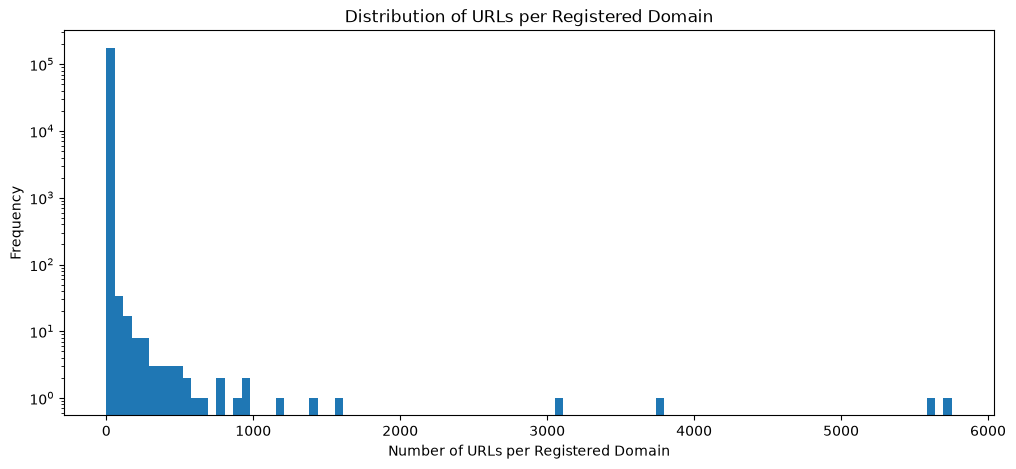

In [71]:
per_domain.plot(kind="hist", bins=100, logy=True, figsize=(12,5), title="Distribution of URLs per Registered Domain", xlabel="Number of URLs per Registered Domain")
plt.savefig("../reports/figures/urls_per_registered_domain.png", dpi=300, bbox_inches="tight")

The plot confirms the pattern. Most registered domains appear only once, while a small number occur hundreds or thousands of times. 

In [78]:
top20 = per_domain.head(20)
contribution_of_top20 = top20.sum() / len(df) * 100
print(f"The top 20 registered domains contribute {contribution_of_top20:.2f}% of the total URLs in the dataset.")

The top 20 registered domains contribute 13.18% of the total URLs in the dataset.


In [91]:
by_domain = df.groupby("registered_domain")["label"].nunique()
mixed = by_domain[by_domain > 1]
print(f"There are {len(mixed)} registered domains that have both phishing and legitimate URLs.")
df[df["registered_domain"].isin(mixed.index[:10])][["URL", "label"]]

There are 120 registered domains that have both phishing and legitimate URLs.


,URL,label
681,https://jnlklknlknlk.agilecrm.com/landing/5390...,0
16377,https://indd.adobe.com/view/238eae4e-7809-488b...,0
16501,http://www.plight.altervista.org,0
18289,http://www.1x.com,0
28127,https://www.airlinemeals.net,1
36788,https://www.acm.org,1
37992,http://www.headuphigh.art.pl,0
42707,https://www.agilecrm.com,1
49956,https://www.amna.gr,1
56772,https://express.adobe.com/page/soupu5tptgdrk/,0


In [98]:
df.loc[df["registered_domain"] == "", "URL"].head(10).tolist()

['http://198.98.58.123/',
 'http://43.134.167.94/servicelogin?passive=1209600&amp;continue=https://accounts.google.com/?&amp;xrealip=107.178.232.242&amp;followup=https://accounts.google.com/?&amp;xrealip=107.178.232.242',
 'http://43.128.92.128/servicelogin?passive=1209600&amp;continue=https://accounts.google.com/?&amp;xrealip=107.178.232.247&amp;followup=https://accounts.google.com/?',
 'http://43.134.167.94/v3/signin/identifier?dsh=s151927330%3a1679418096294349&amp%3bfollowup=https%3a%2f%2faccounts.google.com%2f%3f&amp%3bifkv=aqmjq7que0i0y0zqvxr-psd9dopzofl1azrhfrg8jha1fo5atztmzkxpzsdd8dd9wxed0vlkukpb&amp%3bpassive=1209600&amp%3bxrealip=107.178.232.242&continue=https%3a%2f%2faccounts.google.com%2f%3f&xrealip=107.21.207.171&flowname=weblitesignin&flowentry=servicelogin&ifkv=awnoghdd3bcsqfutafhqg0s1jix1d0uxzq28f0tkgnl9zhq-dfvgzt7n2gzib78ijohixqaaraothg',
 'http://43.153.207.103/v3/signin/identifier?dsh=s-16339560%3a1679418180081355&amp%3bfollowup=https%3a%2f%2faccounts.google.com%2f%3f

In [99]:
df.loc[df["registered_domain"] == "", "label"].value_counts()

label
0    608
Name: count, dtype: int64

In [102]:
weird = (df["registered_domain"] == "").sum()
print(f"There are {weird} URLs that do not have a registered domain. These are likely malformed URLs or IP addresses.")

There are 608 URLs that do not have a registered domain. These are likely malformed URLs or IP addresses.
